In [2]:
%pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:

df = pd.read_csv('HousingData.csv')


print(df.shape)

print(f"\nпропусков: {df.isnull().sum().sum()}")

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print(f"\nпропусков: {df.isnull().sum().sum()}")       

print(df.describe())

(506, 14)

пропусков: 120


<ipython-input-6-1eb6a71e76a5>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-6-1eb6a71e76a5>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 


пропусков: 0
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.479140   10.768775   11.028893    0.067194    0.554695    6.284634   
std      8.570832   23.025124    6.704679    0.250605    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.083235    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.253715    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      2.808720    0.000000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.845850    3.795043    9.549407  408.237154   18.455534  356.674032   
std     27.48

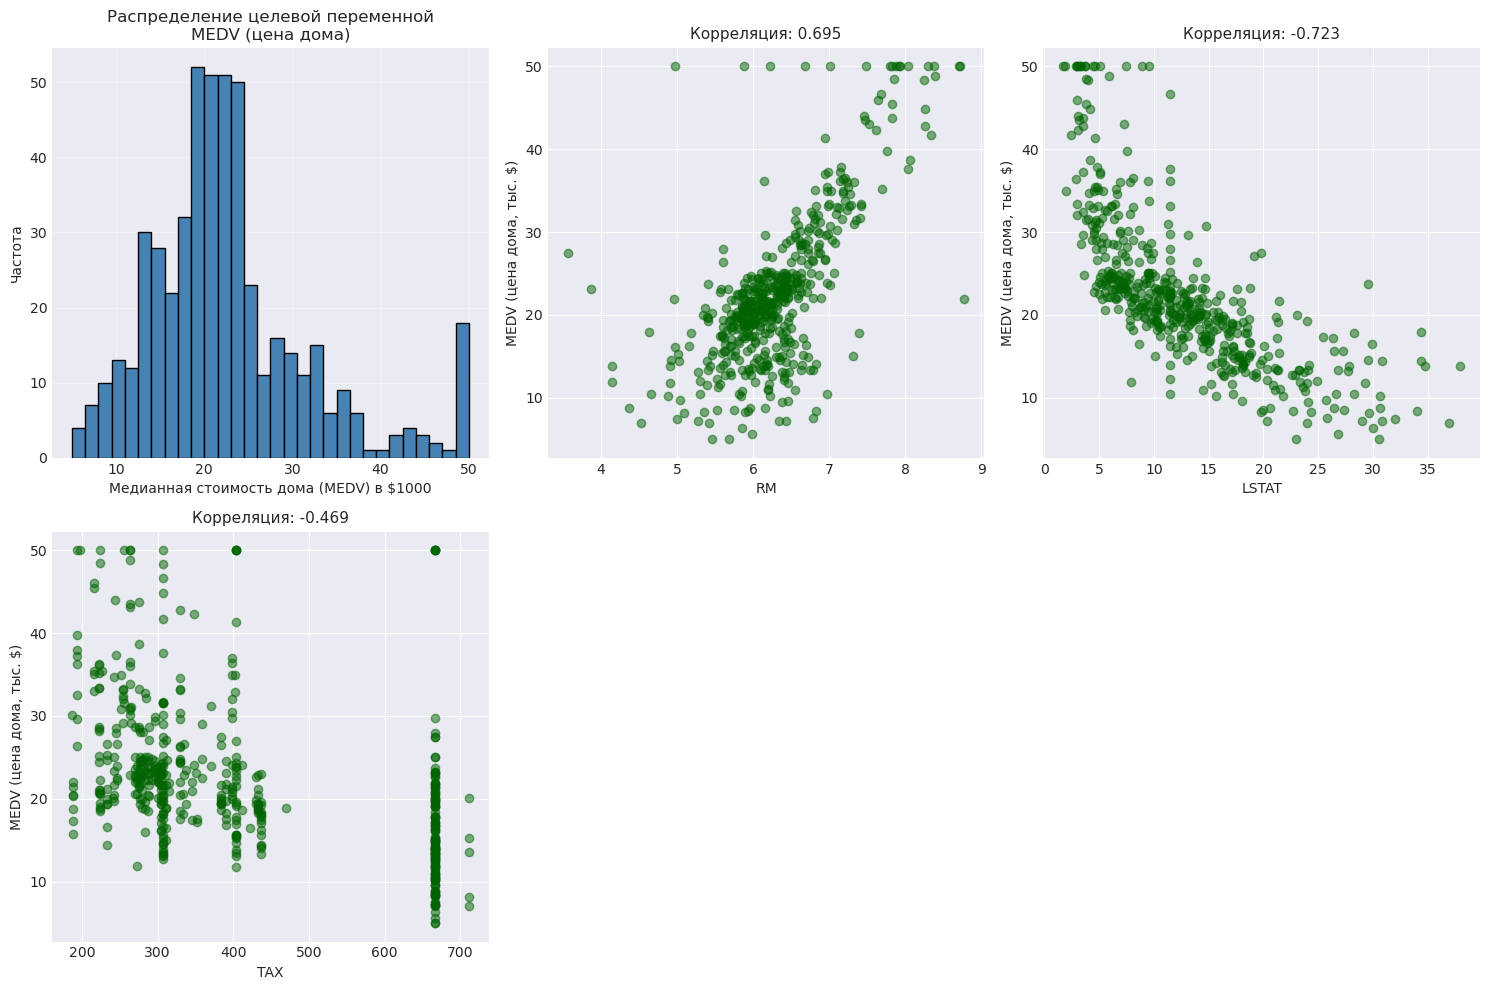

In [10]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']


plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.hist(y, bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Медианная стоимость дома (MEDV) в $1000')
plt.ylabel('Частота')
plt.title('Распределение целевой переменной\nMEDV (цена дома)')
plt.grid(True, alpha=0.3)


selected_features = ['RM', 'LSTAT', 'TAX']


for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i + 1)
    plt.scatter(X[feature], y, alpha=0.5, color='darkgreen')
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('MEDV (цена дома, тыс. $)')
    corr = X[feature].corr(y)
    plt.title(f'Корреляция: {corr:.3f}', fontsize=11)
plt.tight_layout()
plt.show()


In [19]:
from sklearn.preprocessing import StandardScaler
X_selected = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)


lr_original = LinearRegression()
lr_original.fit(X_train, y_train)

print( f'1 комната = {lr_original.coef_[0]:.2f} тыс. $')
print(f'1% населения низкого статуса = {lr_original.coef_[1]:.2f} тыс. $')
print(f'1$ налога за 10000$ стоимости = {lr_original.coef_[2]:.4f} тыс. $')

print(f"базово дом стоит {lr_original.intercept_:.2f} тыс. $")

print(f"MAE {mae_lr:.4f}")
print(f"MSE {mse_lr:.4f}")
print(f"R2 {r2_lr:.4f}")


1 комната = 5.36 тыс. $
1% населения низкого статуса = -0.57 тыс. $
1$ налога за 10000$ стоимости = -0.0068 тыс. $
базово дом стоит -1.08 тыс. $
MAE 3.8978
MSE 28.3653
R2 0.6193


MAE: 3.5174
R2:  0.6813


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


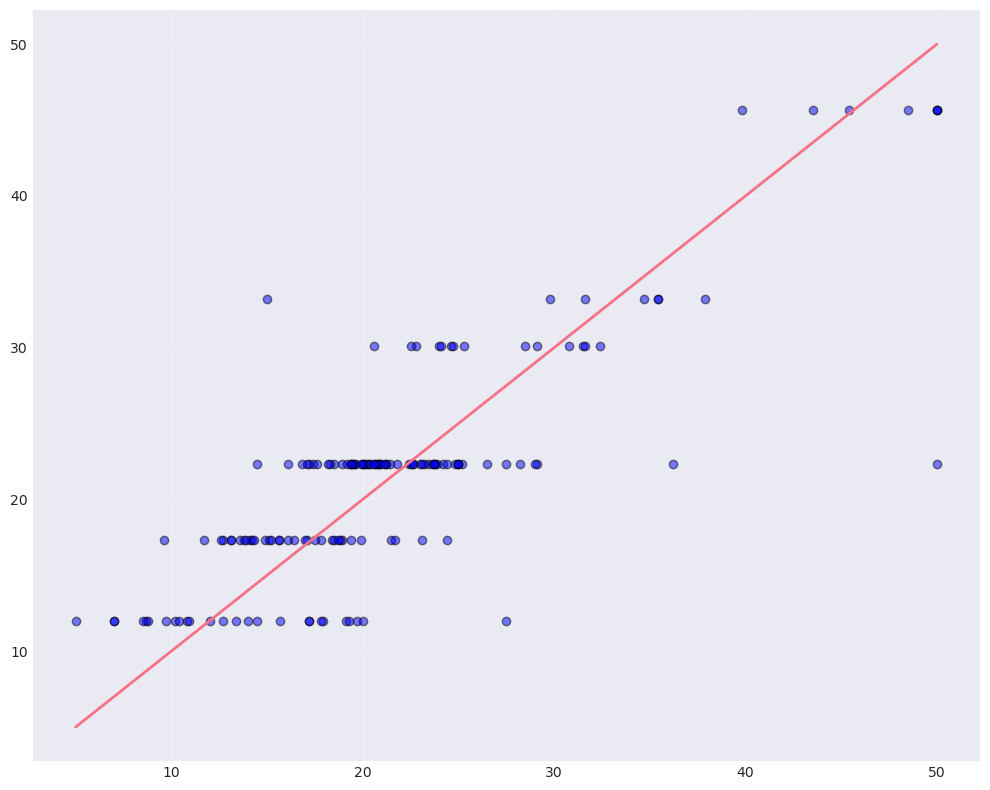

In [23]:
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train_scaled, y_train)


y_pred_dt = dt.predict(X_test_scaled)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"MAE: {mae_dt:.4f}")
print(f"R2:  {r2_dt:.4f}")


best_pred = y_pred_dt


plt.figure(figsize=(10, 8))


plt.scatter(y_test, best_pred, alpha=0.5, color='blue', edgecolors='black')

min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2,)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
np.random.seed(42)

n_noise_features = 30
n_train = X_train_scaled.shape[0]
n_test = X_test_scaled.shape[0]


noise_train = np.random.randn(n_train, n_noise_features)
noise_test = np.random.randn(n_test, n_noise_features)

X_train_noisy = np.hstack([X_train_scaled, noise_train])
X_test_noisy = np.hstack([X_test_scaled, noise_test])

scaler_noisy = StandardScaler()
X_train_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_scaled = scaler_noisy.transform(X_test_noisy)

In [28]:
broken_lr = LinearRegression()
broken_lr.fit(X_train_noisy_scaled, y_train)

# Предсказания
y_train_pred_broken = broken_lr.predict(X_train_noisy_scaled)
y_test_pred_broken = broken_lr.predict(X_test_noisy_scaled)

r2_train_broken = r2_score(y_train, y_train_pred_broken)
r2_test_broken = r2_score(y_test, y_test_pred_broken)
mae_test_broken = mean_absolute_error(y_test, y_test_pred_broken)

print(f"R2 train: {r2_train_broken:.6f}")
print(f"R2 test:  {r2_test_broken:.6f}")
print(f"MAE на test: {mae_test_broken:.4f}")
print(f"Разница: {r2_lr - r2_test_broken:.6f}")

R2 train: 0.672387
R2 test:  0.602225
MAE на test: 3.9768
Разница: 0.017099


In [33]:
from sklearn.linear_model import Ridge

alpha_values = [0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_noisy_scaled, y_train)
    
    y_test_pred_ridge = ridge.predict(X_test_noisy_scaled)
    ridge_results.append(r2_score(y_test, y_test_pred_ridge))

best_ridge = max(ridge_results)

print(f"лучшее a = {best_alpha} с r2 = {best_ridge}")


final_ridge = Ridge(alpha=best_alpha, random_state=42)
final_ridge.fit(X_train_noisy_scaled, y_train)
y_train_pred_final = final_ridge.predict(X_train_noisy_scaled)
y_test_pred_final = final_ridge.predict(X_test_noisy_scaled)

r2_train_final = r2_score(y_train, y_train_pred_final)
r2_test_final = r2_score(y_test, y_test_pred_final)


лучшее a = 100 с r2 = 0.6150756755520761


Базовая (предыдущая практика) - 0.6193

Сломанная (LinearRegression + шум) - 0.602225

Исправленная (Ridge + шум, alpha = 100) - 0.615075


Насколько упало качество после добавления шума? 0.017099
При каком alpha Ridge показал лучший результат? 100
Удалось ли вернуть качество к базовому уровню? Насколько близко? да близко
